In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization
import numpy as np
from sklearn.metrics import accuracy_score

In [82]:
df=pd.read_csv("NIST DATABASE.csv")

In [83]:
df.head()

,1.24E+05,9.62E+04,9.66E+04,3.90E+04,1.80E+04,9.16E+03,2.78E+04,5.65E+04,6.70E+04,1.02E+05,...,2.02E+04.1,1.74E+04,1.36E+04.1,8.16E+03,1.09E+04.2,1.16E+04,1.15E+04.1,8.39E+03,1.38E+04.1,1
0,5920.0,6550.0,7020.0,3800.0,18400.0,36500.0,10100.0,4460.0,6450.0,2230.0,...,47500.0,5660.0,5780.0,6180.0,7760.0,15800.0,32000.0,3930.0,14100.0,1
1,4580.0,3910.0,2200.0,3150.0,3310.0,5850.0,4800.0,4460.0,10500.0,789.0,...,82100.0,8380.0,13000.0,9990.0,19900.0,10700.0,33300.0,2730.0,14100.0,1
2,1900.0,2810.0,4510.0,3700.0,6090.0,12300.0,2010.0,1850.0,2720.0,1820.0,...,110000.0,1990.0,5010.0,9230.0,3870.0,19100.0,62600.0,4940.0,14200.0,1
3,4650.0,3050.0,1260.0,1540.0,4790.0,13500.0,12000.0,6080.0,1910.0,2140.0,...,87400.0,12400.0,8680.0,4630.0,3700.0,10700.0,24900.0,4760.0,13700.0,1
4,1320.0,1320.0,1650.0,9050.0,7130.0,37800.0,38500.0,3690.0,1590.0,1300.0,...,130000.0,7880.0,4500.0,3900.0,5660.0,4580.0,11000.0,3520.0,13800.0,1


In [84]:
df.iloc[:, -1].value_counts()

1
2    170
3    111
1     79
4     50
5     50
Name: count, dtype: int64

In [85]:
x = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column (class)

In [86]:
mapping = {1:0, 2:1, 3:2, 4:3, 5:4}
y = y.map(mapping)

In [87]:
x.shape

(460, 152)

In [88]:
y.isnull().sum()

np.int64(0)

In [89]:
from sklearn.model_selection import train_test_split

# X: Features, y: Target labels
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)


In [90]:
y_train.shape

(345,)

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [92]:
from sklearn.model_selection import train_test_split

# Split your existing training data (x_train, y_train) 
# into a smaller training set and a validation set
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print(f"New Training size: {x_train_sub.shape[0]}")
print(f"Validation size: {x_val.shape[0]}")

New Training size: 276
Validation size: 69


In [93]:
# Step 3: FLANN Feature Expansion
import numpy as np

def flann_expand(x):
    return np.hstack([x, np.sin(x), np.cos(x), x**2,np.sin(2*x),np.cos(2*x),2*(x**2)-1,])

x_test_expanded = flann_expand(x_test)
x_train_expanded = flann_expand(x_train_sub)
x_val_expanded = flann_expand(x_val)

In [94]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit and transform the training data ONLY
x_train_scaled = scaler.fit_transform(x_train_expanded)
# Transform validation and test using training parameters
x_val_scaled = scaler.transform(x_val_expanded)
x_test_scaled = scaler.transform(x_test_expanded)

In [95]:
x_train

array([[-0.54856677, -0.50571229, -0.52196888, ..., -0.65661313,
        -1.06085519, -0.40033043],
       [-0.62301603, -0.5549169 , -0.49530301, ...,  1.88274098,
         0.37361099,  1.22046213],
       [-0.40720741, -0.55216633, -0.55716783, ..., -0.68203492,
        -0.71976062, -0.40033043],
       ...,
       [-0.65332531, -0.58686474, -0.47322288, ..., -0.40228678,
        -0.27586177, -0.58202196],
       [-0.42417053, -0.4207503 , -0.55076802, ..., -0.6766681 ,
        -0.85526394,  0.81526399],
       [-0.55736246, -0.57967201, -0.57067853, ..., -0.24703989,
        -0.77583096, -1.21072671]], shape=(345, 152))

In [96]:
x_train.shape

(345, 152)

In [97]:
x_test.shape

(115, 152)

In [98]:
print(sorted(y.unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [99]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
x_train_final = pca.fit_transform(x_train_scaled)
x_val_final = pca.transform(x_val_scaled)
x_test_final = pca.transform(x_test_scaled)

# Check the result
print(f"Original features: 608")
print(f"Reduced features (95% variance): {x_train.shape[1]}")

Original features: 608
Reduced features (95% variance): 152


In [100]:
print("Shape after PCA:", x_train.shape)

Shape after PCA: (345, 152)


FLANN

In [101]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=x_train.shape[1]))
model.add(Dropout(0.3))  
# Only ONE layer (FLANN style)
model.add(Dense(
    units=5,              # 5 classes ()
    input_dim=608,        # your expanded features
    activation='softmax'  # multi-class classification
))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\chakr\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           9,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,117 (39.52 KB)

 Trainable params: 10,117 (39.52 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
print(y_train.shape)
print(x_train.shape)

(345,)
(345, 152)


In [103]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

es=early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6,
                        min_lr=1e-6, mode='min', verbose=1)
mc  = ModelCheckpoint('EVOLUTIONARY ALGORITHM BASED HYBRID FLANN FOR FINGERPRINT CLASSIFICATION.keras',
                      monitor='val_loss', mode='min',
                      save_best_only=True, verbose=1)

In [104]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50, batch_size=64, shuffle=True,
    callbacks=[es,rlr,mc], verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2942 - loss: 2.0933
Epoch 1: val_loss improved from None to 1.51850, saving model to EVOLUTIONARY ALGORITHM BASED HYBRID FLANN FOR FINGERPRINT CLASSIFICATION.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step - accuracy: 0.2986 - loss: 1.9555 - val_accuracy: 0.4261 - val_loss: 1.5185 - learning_rate: 0.0010
Epoch 2/50
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4688 - loss: 1.4280
Epoch 2: val_loss improved from 1.51850 to 1.15544, saving model to EVOLUTIONARY ALGORITHM BASED HYBRID FLANN FOR FINGERPRINT CLASSIFICATION.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5246 - loss: 1.2954 - val_accuracy: 0.5826 - val_loss: 1.1554 - learning_rate: 0.0010
Epoch 3/50
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5781 - loss: 1.2356
Epoch 3: val_loss improved from 1.15544 to 0.99419, saving model to EVOLUTIONARY ALGORITHM BASED HYBRID FLANN FOR FINGERPRINT CLASSIFICATION.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/ste

In [105]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


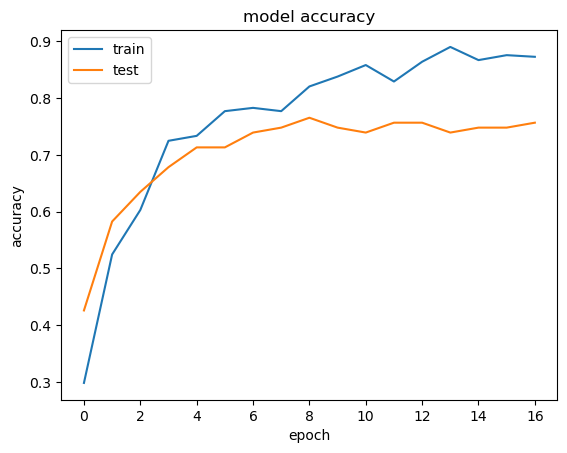

In [106]:

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

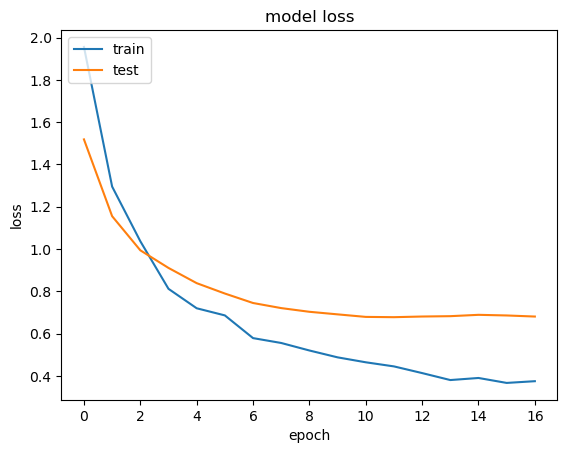

In [107]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [108]:
# Part 3 - Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([[False,  True, False, False, False],
       [ True, False, False, False, False],
       [False,  True, False, False, False],
       [ True, False, False, False, False],
       [False, False,  True, False, False],
       [False,  True, False, False, False],
       [False, False, False, False,  True],
       [False, False,  True, False, False],
       [False,  True, False, False, False],
       [ True, False, False, False, False],
       [ True, False, False, False, False],
       [False,  True, False, False, False],
       [ True, False, False, False, False],
       [False, False,  True, False, False],
       [False,  True, False, False, False],
       [False, False, False, False, False],
       [False,  True, False, False, False],
       [False,  True, False, False, False],
       [ True, False, False, False, False],
       [ True, False, False, False, False],
       [ True, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, Fal

In [109]:
print('y_test shape/type:', np.array(y_test).shape)
print('y_pred shape/type:', np.array(y_pred).shape)


y_test shape/type: (115,)
y_pred shape/type: (115, 5)


In [110]:
y_pred = np.argmax(y_pred, axis=1)

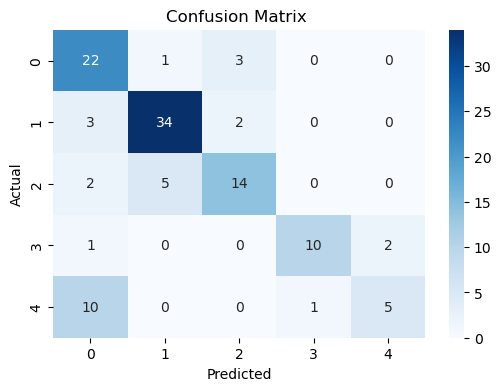

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix ')

plt.show()

In [112]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [113]:
score

0.7391304347826086